# 7CS353 Machine Learning Lab &mdash; Assignment 5
### Simple Linear Regression: Normal Equation, Gradient Descent, and Model Analysis

**Name:** Atharv V Kulkarni
**PRN:** 245109074
**Class:** TY B.Tech CSE (B)

## Section 0: Load Dataset and Separate Classes

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy import stats

df=pd.read_excel("Dataset_A5.xlsx")
df.shape

(156, 6)

In [3]:
df.head()

,Timestamp,division,height_cm,height_in,weight_kg,weight_lb
0,2026-08-22 15:43:04.048,TY-B,164,5.45,72,158
1,2026-08-22 15:43:20.944,TY-B,177,70,71,154
2,2026-08-22 15:43:21.342,TY-B,180,70,54,119
3,2026-08-22 15:43:35.510,TY-B,180,71,68,150
4,2026-08-22 15:43:44.474,TY-A,180,NaN,85,NaN


## B.1 Load and Explore

**B1:** clean the raw columns (they contain mixed units and text as collected via Google Form), handle missing values, then determine which class is taller and which is heavier

In [4]:
def strip_unit(val):
    if pd.isna(val):
        return np.nan
    s=str(val).strip()
    if s in [".",""]:
        return np.nan
    m=re.search(r"[-+]?\d*\.?\d+",s)
    if m:
        return float(m.group())
    return np.nan

In [5]:
df["height_cm"]=df["height_cm"].apply(strip_unit)
df["weight_kg"]=df["weight_kg"].apply(strip_unit)

df=df.dropna(subset=["division","height_cm","weight_kg"])

df=df[(df["height_cm"].between(120,220))&(df["weight_kg"].between(30,150))]

df_a=df[df["division"]=="TY-A"].reset_index(drop=True)
df_b=df[df["division"]=="TY-B"].reset_index(drop=True)

print("TY-A rows:",len(df_a),"TY-B rows:",len(df_b))
print("TY-A mean height:",df_a["height_cm"].mean(),"TY-B mean height:",df_b["height_cm"].mean())
print("TY-A mean weight:",df_a["weight_kg"].mean(),"TY-B mean weight:",df_b["weight_kg"].mean())

TY-A rows: 66 TY-B rows: 87
TY-A mean height: 168.2669696969697 TY-B mean height: 170.68772413793104
TY-A mean weight: 60.700909090909086 TY-B mean weight: 61.41149425287357


**B2:** scatter plot of height_cm vs weight_kg for both classes on one figure

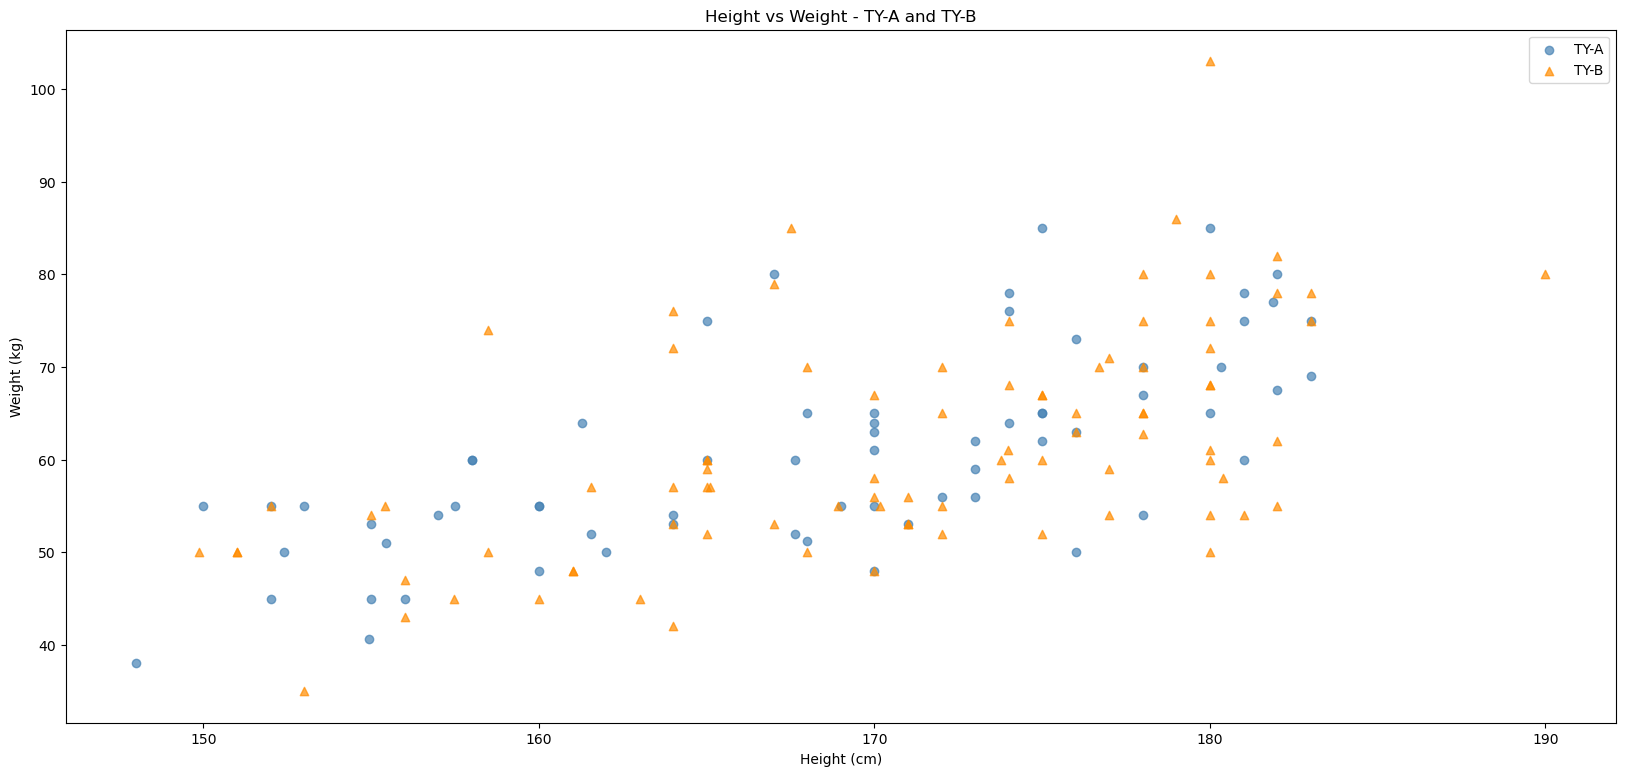

In [6]:
plt.figure(figsize=(20,9))
plt.scatter(df_a["height_cm"],df_a["weight_kg"],color="steelblue",marker="o",alpha=0.7,label="TY-A")
plt.scatter(df_b["height_cm"],df_b["weight_kg"],color="darkorange",marker="^",alpha=0.7,label="TY-B")
plt.title("Height vs Weight - TY-A and TY-B")
plt.xlabel("Height (cm)")
plt.ylabel("Weight (kg)")
plt.legend()
plt.show()

## B.2 Correlation Analysis

**B3:** correlation matrix and heatmap for all four columns, for each class separately

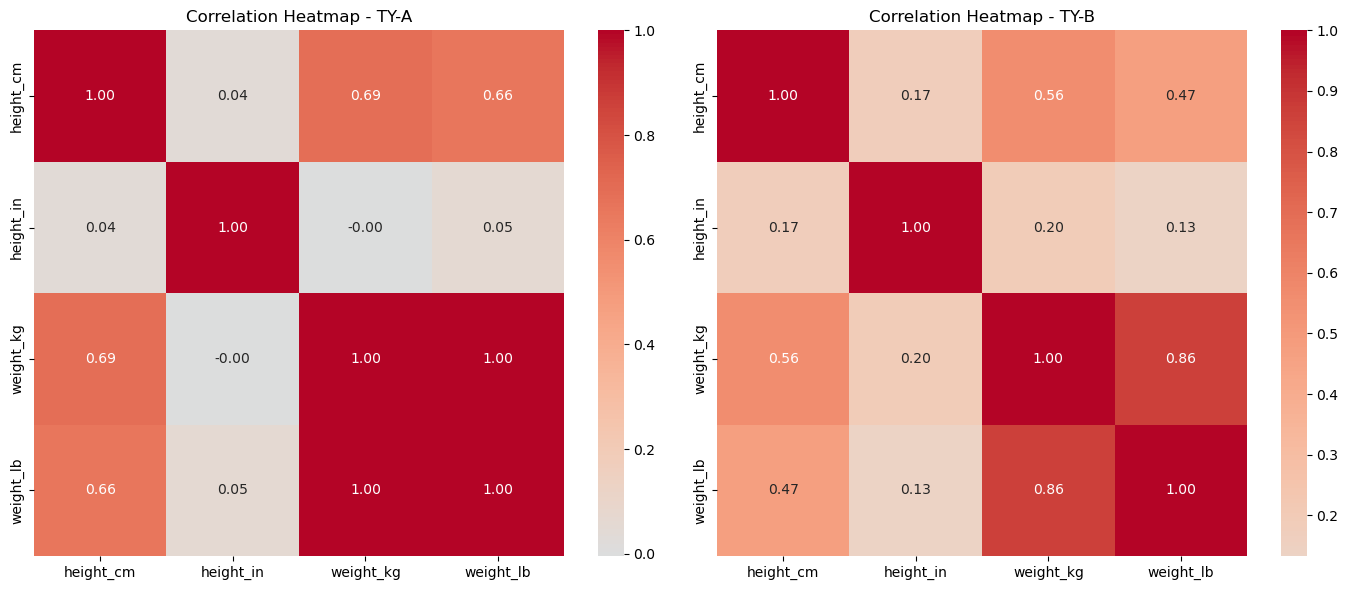

           height_cm  height_in  weight_kg  weight_lb
height_cm      1.000      0.036      0.693      0.662
height_in      0.036      1.000     -0.004      0.055
weight_kg      0.693     -0.004      1.000      1.000
weight_lb      0.662      0.055      1.000      1.000
           height_cm  height_in  weight_kg  weight_lb
height_cm      1.000      0.175      0.563      0.472
height_in      0.175      1.000      0.197      0.133
weight_kg      0.563      0.197      1.000      0.860
weight_lb      0.472      0.133      0.860      1.000
TY-A height-weight r: 0.6932340727326465 p-value: 1.1122311318435696e-10
TY-B height-weight r: 0.562565882263389 p-value: 1.4206967030254279e-08


In [9]:
df_a_num=df_a[["height_cm","height_in","weight_kg","weight_lb"]].apply(pd.to_numeric,errors="coerce")
df_b_num=df_b[["height_cm","height_in","weight_kg","weight_lb"]].apply(pd.to_numeric,errors="coerce")

corr_a=df_a_num.corr()
corr_b=df_b_num.corr()

fig,ax=plt.subplots(1,2,figsize=(14,6))
sns.heatmap(corr_a,annot=True,cmap="coolwarm",center=0,fmt=".2f",ax=ax[0])
ax[0].set_title("Correlation Heatmap - TY-A")
sns.heatmap(corr_b,annot=True,cmap="coolwarm",center=0,fmt=".2f",ax=ax[1])
ax[1].set_title("Correlation Heatmap - TY-B")
plt.tight_layout()
plt.show()

print(corr_a.round(3))
print(corr_b.round(3))

r_a,p_a=stats.pearsonr(df_a_num["height_cm"].dropna(),df_a_num["weight_kg"].dropna())
r_b,p_b=stats.pearsonr(df_b_num["height_cm"].dropna(),df_b_num["weight_kg"].dropna())
print("TY-A height-weight r:",r_a,"p-value:",p_a)
print("TY-B height-weight r:",r_b,"p-value:",p_b)

## B.3 Normal Equation

**B4:** determine beta0 and beta1 for both classes using only NumPy, verify against sklearn LinearRegression

In [10]:
def normal_equation(x,y):
    x_mean=x.mean()
    y_mean=y.mean()
    beta1=np.sum((x-x_mean)*(y-y_mean))/np.sum((x-x_mean)**2)
    beta0=y_mean-beta1*x_mean
    return beta0,beta1

beta0_a,beta1_a=normal_equation(df_a["height_cm"].values,df_a["weight_kg"].values)
beta0_b,beta1_b=normal_equation(df_b["height_cm"].values,df_b["weight_kg"].values)
print("TY-A: beta0=",beta0_a,"beta1=",beta1_a)
print("TY-B: beta0=",beta0_b,"beta1=",beta1_b)

lr_a=LinearRegression().fit(df_a[["height_cm"]],df_a["weight_kg"])
lr_b=LinearRegression().fit(df_b[["height_cm"]],df_b["weight_kg"])
print("sklearn TY-A: intercept=",lr_a.intercept_,"coef=",lr_a.coef_)
print("sklearn TY-B: intercept=",lr_b.intercept_,"coef=",lr_b.coef_)

TY-A: beta0= -67.81732113997984 beta1= 0.7637757455449284
TY-B: beta0= -63.73361843996622 beta1= 0.7331816820740504
sklearn TY-A: intercept= -67.81732113997987 coef= [0.76377575]
sklearn TY-B: intercept= -63.73361843996611 coef= [0.73318168]


**B5:** scatter plot with fitted regression line for each class, equation labelled on the plot

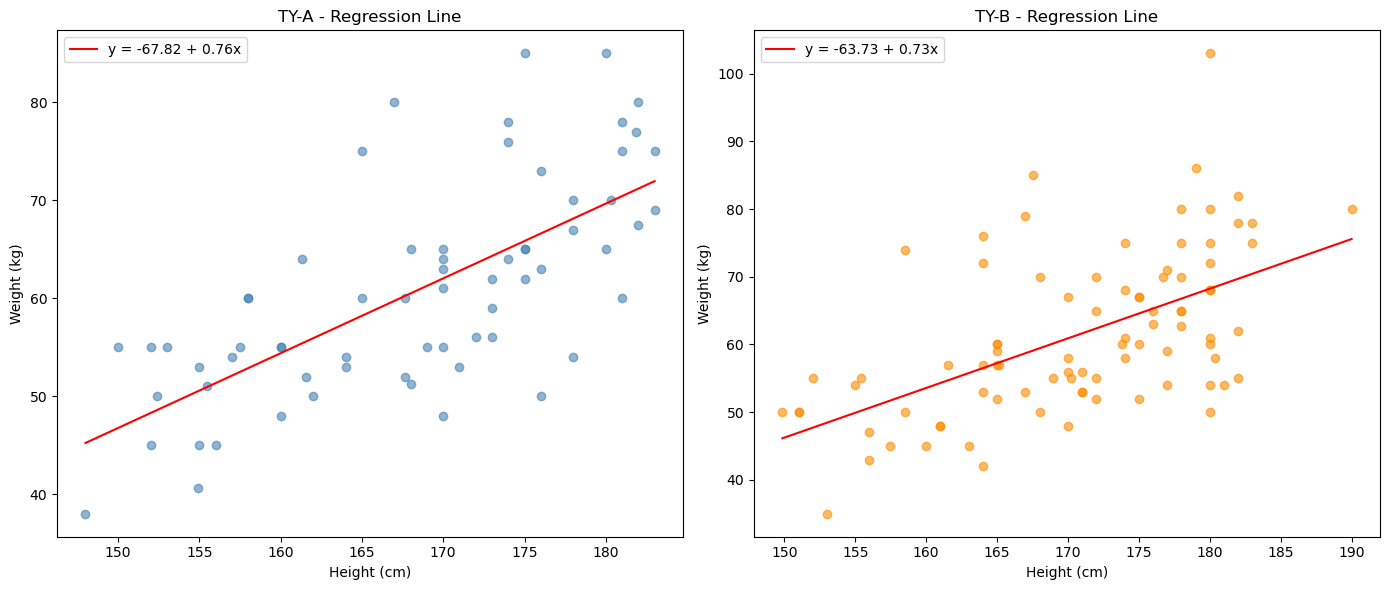

In [11]:
fig,ax=plt.subplots(1,2,figsize=(14,6))
x_a=np.linspace(df_a["height_cm"].min(),df_a["height_cm"].max(),100)
ax[0].scatter(df_a["height_cm"],df_a["weight_kg"],alpha=0.6,color="steelblue")
ax[0].plot(x_a,beta0_a+beta1_a*x_a,color="red",label=f"y = {beta0_a:.2f} + {beta1_a:.2f}x")
ax[0].set_title("TY-A - Regression Line")
ax[0].set_xlabel("Height (cm)")
ax[0].set_ylabel("Weight (kg)")
ax[0].legend()

x_b=np.linspace(df_b["height_cm"].min(),df_b["height_cm"].max(),100)
ax[1].scatter(df_b["height_cm"],df_b["weight_kg"],alpha=0.6,color="darkorange")
ax[1].plot(x_b,beta0_b+beta1_b*x_b,color="red",label=f"y = {beta0_b:.2f} + {beta1_b:.2f}x")
ax[1].set_title("TY-B - Regression Line")
ax[1].set_xlabel("Height (cm)")
ax[1].set_ylabel("Weight (kg)")
ax[1].legend()
plt.tight_layout()
plt.show()

## B.4 Gradient Descent - sklearn SGDRegressor

**B6:** fit SGDRegressor for each class without scaling, compare with Normal Equation results

In [12]:
sgd_a=SGDRegressor(max_iter=1000,random_state=42)
sgd_a.fit(df_a[["height_cm"]],df_a["weight_kg"])
sgd_b=SGDRegressor(max_iter=1000,random_state=42)
sgd_b.fit(df_b[["height_cm"]],df_b["weight_kg"])

print("SGD TY-A (unscaled): intercept=",sgd_a.intercept_,"coef=",sgd_a.coef_)
print("SGD TY-B (unscaled): intercept=",sgd_b.intercept_,"coef=",sgd_b.coef_)
print("Normal Equation TY-A: beta0=",beta0_a,"beta1=",beta1_a)
print("Normal Equation TY-B: beta0=",beta0_b,"beta1=",beta1_b)

SGD TY-A (unscaled): intercept= [-5.68611514e+09] coef= [-1.8988726e+11]
SGD TY-B (unscaled): intercept= [-5.9313225e+09] coef= [-5.53910533e+10]
Normal Equation TY-A: beta0= -67.81732113997984 beta1= 0.7637757455449284
Normal Equation TY-B: beta0= -63.73361843996622 beta1= 0.7331816820740504


**B7:** fit SGDRegressor after StandardScaler, recover original-scale beta0 and beta1

In [13]:
scaler_a=StandardScaler().fit(df_a[["height_cm"]])
Xa_scaled=scaler_a.transform(df_a[["height_cm"]])
sgd_a_scaled=SGDRegressor(max_iter=1000,random_state=42)
sgd_a_scaled.fit(Xa_scaled,df_a["weight_kg"])

scaler_b=StandardScaler().fit(df_b[["height_cm"]])
Xb_scaled=scaler_b.transform(df_b[["height_cm"]])
sgd_b_scaled=SGDRegressor(max_iter=1000,random_state=42)
sgd_b_scaled.fit(Xb_scaled,df_b["weight_kg"])

beta1_a_sgd=sgd_a_scaled.coef_[0]/scaler_a.scale_[0]
beta0_a_sgd=sgd_a_scaled.intercept_[0]-beta1_a_sgd*scaler_a.mean_[0]

beta1_b_sgd=sgd_b_scaled.coef_[0]/scaler_b.scale_[0]
beta0_b_sgd=sgd_b_scaled.intercept_[0]-beta1_b_sgd*scaler_b.mean_[0]

print("SGD TY-A (scaled, recovered): beta0=",beta0_a_sgd,"beta1=",beta1_a_sgd)
print("SGD TY-B (scaled, recovered): beta0=",beta0_b_sgd,"beta1=",beta1_b_sgd)

SGD TY-A (scaled, recovered): beta0= -67.66604188746945 beta1= 0.762654716483368
SGD TY-B (scaled, recovered): beta0= -63.78107633034163 beta1= 0.7334040498959048


## B.5 Error Metrics

**B8:** four NumPy metric functions from scratch, applied to Normal Equation and SGDRegressor predictions for both classes

In [14]:
def mae(y_true,y_pred):
    return np.mean(np.abs(y_true-y_pred))

def mse(y_true,y_pred):
    return np.mean((y_true-y_pred)**2)

def rmse(y_true,y_pred):
    return np.sqrt(mse(y_true,y_pred))

def r_squared(y_true,y_pred):
    sse=np.sum((y_true-y_pred)**2)
    sst=np.sum((y_true-y_true.mean())**2)
    return 1-sse/sst

pred_a_ne=beta0_a+beta1_a*df_a["height_cm"].values
pred_b_ne=beta0_b+beta1_b*df_b["height_cm"].values
pred_a_sgd=beta0_a_sgd+beta1_a_sgd*df_a["height_cm"].values
pred_b_sgd=beta0_b_sgd+beta1_b_sgd*df_b["height_cm"].values

results=pd.DataFrame({
    "Class":["TY-A","TY-A","TY-B","TY-B"],
    "Method":["Normal Equation","SGDRegressor","Normal Equation","SGDRegressor"],
    "MAE":[mae(df_a["weight_kg"].values,pred_a_ne),mae(df_a["weight_kg"].values,pred_a_sgd),
           mae(df_b["weight_kg"].values,pred_b_ne),mae(df_b["weight_kg"].values,pred_b_sgd)],
    "MSE":[mse(df_a["weight_kg"].values,pred_a_ne),mse(df_a["weight_kg"].values,pred_a_sgd),
           mse(df_b["weight_kg"].values,pred_b_ne),mse(df_b["weight_kg"].values,pred_b_sgd)],
    "RMSE":[rmse(df_a["weight_kg"].values,pred_a_ne),rmse(df_a["weight_kg"].values,pred_a_sgd),
            rmse(df_b["weight_kg"].values,pred_b_ne),rmse(df_b["weight_kg"].values,pred_b_sgd)],
    "R2":[r_squared(df_a["weight_kg"].values,pred_a_ne),r_squared(df_a["weight_kg"].values,pred_a_sgd),
          r_squared(df_b["weight_kg"].values,pred_b_ne),r_squared(df_b["weight_kg"].values,pred_b_sgd)]
})
print(results.round(4))

print("sklearn r2 check TY-A NE:",r2_score(df_a["weight_kg"].values,pred_a_ne))
print("sklearn r2 check TY-B NE:",r2_score(df_b["weight_kg"].values,pred_b_ne))

  Class           Method     MAE      MSE    RMSE      R2
0  TY-A  Normal Equation  6.0393  59.3250  7.7023  0.4806
1  TY-A     SGDRegressor  6.0370  59.3265  7.7024  0.4806
2  TY-B  Normal Equation  7.6426  95.6182  9.7785  0.3165
3  TY-B     SGDRegressor  7.6417  95.6183  9.7785  0.3165
sklearn r2 check TY-A NE: 0.48057347959749264
sklearn r2 check TY-B NE: 0.316480371886785


## B.6 Visualization and Class Comparison

**B9:** single figure per class with regression line and centroid marker

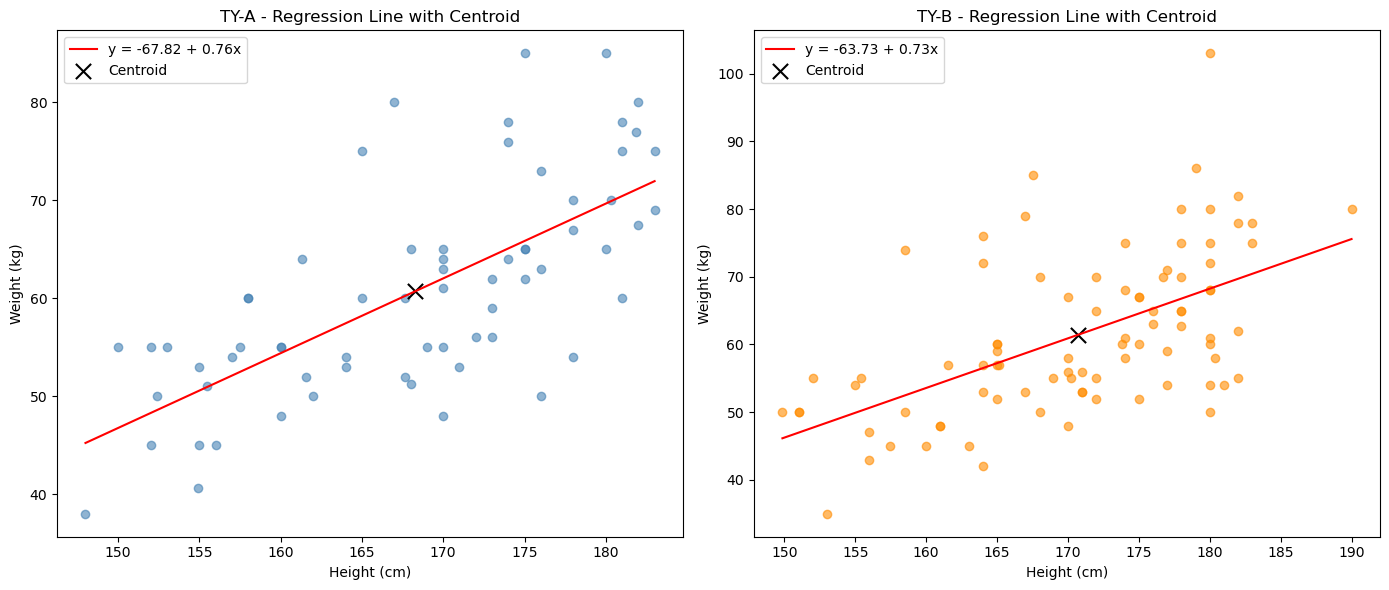

In [15]:
fig,ax=plt.subplots(1,2,figsize=(14,6))
ax[0].scatter(df_a["height_cm"],df_a["weight_kg"],alpha=0.6,color="steelblue")
ax[0].plot(x_a,beta0_a+beta1_a*x_a,color="red",label=f"y = {beta0_a:.2f} + {beta1_a:.2f}x")
ax[0].scatter(df_a["height_cm"].mean(),df_a["weight_kg"].mean(),color="black",marker="x",s=120,label="Centroid")
ax[0].set_title("TY-A - Regression Line with Centroid")
ax[0].set_xlabel("Height (cm)")
ax[0].set_ylabel("Weight (kg)")
ax[0].legend()

ax[1].scatter(df_b["height_cm"],df_b["weight_kg"],alpha=0.6,color="darkorange")
ax[1].plot(x_b,beta0_b+beta1_b*x_b,color="red",label=f"y = {beta0_b:.2f} + {beta1_b:.2f}x")
ax[1].scatter(df_b["height_cm"].mean(),df_b["weight_kg"].mean(),color="black",marker="x",s=120,label="Centroid")
ax[1].set_title("TY-B - Regression Line with Centroid")
ax[1].set_xlabel("Height (cm)")
ax[1].set_ylabel("Weight (kg)")
ax[1].legend()
plt.tight_layout()
plt.show()

**B10:** compare the two class models

## B.7 Take-Home

**B11:** repeat the Normal Equation for TY-A using height_in as X and weight_lb as y

In [16]:
def parse_height_in(val):
    if pd.isna(val):
        return np.nan
    s=str(val).strip().lower()
    s=s.replace('"',"").replace("''","").replace("(","").replace(")","")
    s=s.replace("feet","ft").replace("foot","ft").replace("inches","in").replace("inch","in")
    s=s.strip()
    m=re.match(r"^(\d+)\s*'\s*(\d+\.?\d*)$",s)
    if m:
        return float(m.group(1))*12+float(m.group(2))
    m=re.match(r"^(\d+)\s*ft\s*(\d+\.?\d*)",s)
    if m:
        return float(m.group(1))*12+float(m.group(2))
    m=re.match(r"^(\d+)[,\s]+(\d+\.?\d*)$",s)
    if m:
        feet=float(m.group(1))
        inches=float(m.group(2))
        if feet<=8 and inches<12:
            return feet*12+inches
        return np.nan
    m=re.match(r"^(\d+\.?\d*)\s*in$",s)
    if m:
        return float(m.group(1))
    m=re.match(r"^(\d+\.?\d*)$",s)
    if m:
        return float(m.group(1))
    return np.nan

df_a_take=df_a.copy()
df_a_take["height_in"]=df_a_take["height_in"].apply(parse_height_in)
df_a_take["weight_lb"]=df_a_take["weight_lb"].apply(strip_unit)
df_a_take=df_a_take.dropna(subset=["height_in","weight_lb"])
df_a_take=df_a_take[df_a_take["weight_lb"].between(60,350)]

beta0_in,beta1_in=normal_equation(df_a_take["height_in"].values,df_a_take["weight_lb"].values)
pred_in=beta0_in+beta1_in*df_a_take["height_in"].values
r2_in=r_squared(df_a_take["weight_lb"].values,pred_in)

print("TY-A (inches/pounds): beta0=",beta0_in,"beta1=",beta1_in,"R2=",r2_in)
print("TY-A (cm/kg) for comparison: beta0=",beta0_a,"beta1=",beta1_a,"R2=",r_squared(df_a["weight_kg"].values,pred_a_ne))

TY-A (inches/pounds): beta0= 126.94205693329228 beta1= 0.09291972895494052 R2= 0.0036010564126423006
TY-A (cm/kg) for comparison: beta0= -67.81732113997984 beta1= 0.7637757455449284 R2= 0.48057347959749264
